# Classification

In this Chapter we explore the MNIST dataset, that contains 70000 small images of digits handwritten and labeled with the digit they represent.

In [1]:
# Import dataset from Scikit-Learn
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [2]:
# Explore the arrays data and target
X, y = mnist.data, mnist.target

In [3]:
X.shape

(70000, 784)

In [4]:
y.shape

(70000,)

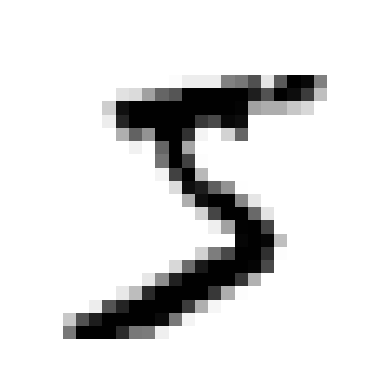

In [5]:
# Take a peek at one digit from the dataset
import matplotlib as mpl
import matplotlib.pyplot as plt

some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)

plt.imshow(some_digit_image, cmap=mpl.cm.binary)
plt.axis('off')
plt.show()

In [6]:
y[0]

'5'

In [7]:
# Cast y to integer
import numpy as np

y = y.astype(np.uint8)

In [8]:
# Create a test set 
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

## Binary Classifier

It is capable of distinguishin between just two classes.

In [9]:
# Create the target vectors for binary classifier
y_train_5 = (y_train == 5) #true for all 5s, False for all other digits
y_test_5 = (y_test == 5)

In [10]:
# Create the Stochastic Gradient Descent (SGD) classifier
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42, n_jobs=-1)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(n_jobs=-1, random_state=42)

In [11]:
sgd_clf.predict([some_digit])

array([ True])

# Perfomance Measures

## Measuring accuracy using cross-validation

In [12]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring='accuracy', n_jobs=-1)

array([0.95035, 0.96035, 0.9604 ])

In [13]:
# Create a dumb classifier that just classifies every single image in the not-5 class
from sklearn.base import BaseEstimator

class Never5Classifier(BaseEstimator):
    def fit(self, X, y=None):
        return self
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)

In [14]:
never_5_clf = Never5Classifier()
cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring='accuracy', n_jobs=-1)

array([0.91125, 0.90855, 0.90915])

Accuracy is not the most suitable way to measure the performance of classifiers, especially when we are dealing with skewed datasets.

## Implementing Cross-Validation

In [15]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))

0.9669
0.91625
0.96785


## Confusion Matrix

In [16]:
#Create a set of predictions ot compare with the actual targets
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, n_jobs=-1)

In [17]:
#Create the confusion matrix
from sklearn.metrics import confusion_matrix

confusion_matrix(y_train_5, y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

### Precision and Recall

In [18]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_5, y_train_pred)

0.8370879772350012

In [19]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

These results mean that when the model claims an image represents 5, it is correct only 83.7% of the time. Moreover, it only detects 65.1% of the 5s.

### F1 Score

Harmonic mean of precision and recall.

In [20]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)

0.7325171197343847

### Threshold Selection

In [21]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method='decision_function')

In [22]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

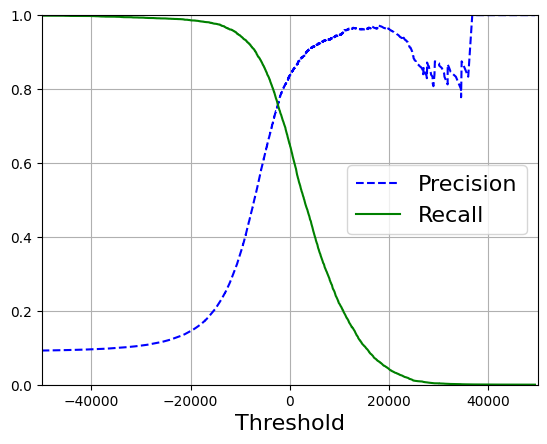

In [23]:
def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
    plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
    plt.legend(loc="center right", fontsize=16)
    plt.xlabel("Threshold", fontsize=16)
    plt.grid(True)                             
    plt.axis([-50000, 50000, 0, 1])  

plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()

In [24]:
#Find the first argument that gives 90% of precision
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]

In [25]:
threshold_90_precision

np.float64(3370.019499144183)

In [26]:
y_train_pred_90 = (y_scores >= threshold_90_precision)

In [27]:
y_train_pred_90

array([False, False, False, ...,  True, False, False])

In [28]:
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [29]:
recall_score(y_train_5, y_train_pred_90)

0.4799852425751706

## The ROC Curve

In [30]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

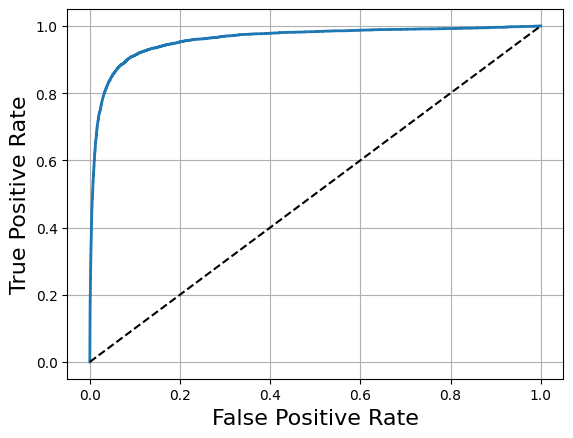

In [31]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') #dashed diagonal
    plt.xlabel("False Positive Rate", fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)
    plt.grid(True)

plot_roc_curve(fpr, tpr)
plt.show()

In [32]:
#Area under the curve (AUC)
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_scores)

np.float64(0.9604938554008616)

## Random Forest Classifier

In [33]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42, n_jobs=-1)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method='predict_proba', n_jobs=-1)

In [34]:
#Use positive class's probability as the score
y_scores_forest = y_probas_forest[:,1]

#ROC Curve
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_5, y_scores_forest)

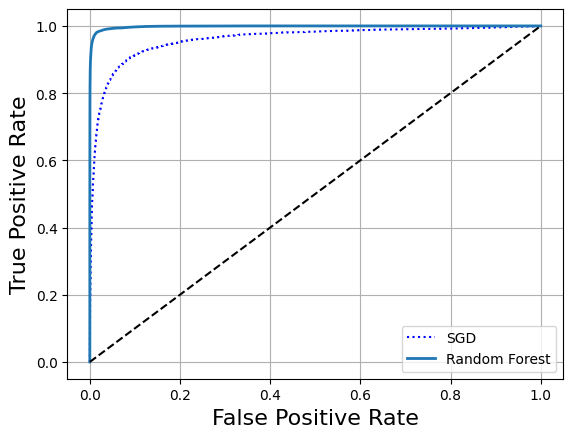

In [35]:
plt.plot(fpr, tpr, 'b:', label='SGD')
plot_roc_curve(fpr_forest, tpr_forest, 'Random Forest')
plt.legend(loc='lower right')
plt.show()

In [36]:
roc_auc_score(y_train_5, y_scores_forest)

np.float64(0.9983296721818179)

## Multiclass Classification

In [37]:
#Support Vector Machine classifier - it uses OvO under the hood
from sklearn.svm import SVC

svm_clf = SVC()
svm_clf.fit(X_train, y_train)
svm_clf.predict([some_digit])

array([5], dtype=uint8)

In [38]:
#Verify decision scores for each class
some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores

array([[ 1.72501977,  2.72809088,  7.2510018 ,  8.3076379 , -0.31087254,
         9.3132482 ,  1.70975103,  2.76765202,  6.23049537,  4.84771048]])

In [39]:
np.argmax(some_digit_scores)

np.int64(5)

In [40]:
svm_clf.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [41]:
svm_clf.classes_[5]

np.uint8(5)

The highest score is indeed the one corresponding to class 5.

In [42]:
#Creat a multiclass classifier using the OvR strategy based on an SVC
from sklearn.multiclass import OneVsRestClassifier
ovr_clf = OneVsRestClassifier(SVC(), n_jobs=-1)
ovr_clf.fit(X_train, y_train)

OneVsRestClassifier(estimator=SVC(), n_jobs=-1)

In [43]:
ovr_clf.predict([some_digit])

array([5], dtype=uint8)

In [44]:
len(ovr_clf.estimators_)

10

In [45]:
#Stochastic Gradient Descent Classifier - multiple classes
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])

array([3], dtype=uint8)

In [46]:
sgd_clf.decision_function([some_digit])

array([[-31893.03095419, -34419.69069632,  -9530.63950739,
          1823.73154031, -22320.14822878,  -1385.80478895,
        -26188.91070951, -16147.51323997,  -4604.35491274,
        -12050.767298  ]])

In [47]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy", n_jobs=-1)

array([0.87365, 0.85835, 0.8689 ])

In [48]:
# Scale the inputs
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))

cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring='accuracy', n_jobs=-1)

array([0.8983, 0.891 , 0.9018])

## Error Analysis

In [49]:
#Make predictions using cross-validation
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3, n_jobs=-1)


In [50]:
#Look at confusion matrix
conf_mx = confusion_matrix(y_train, y_train_pred)
conf_mx

array([[5577,    0,   22,    5,    8,   43,   36,    6,  225,    1],
       [   0, 6400,   37,   24,    4,   44,    4,    7,  212,   10],
       [  27,   27, 5220,   92,   73,   27,   67,   36,  378,   11],
       [  22,   17,  117, 5227,    2,  203,   27,   40,  403,   73],
       [  12,   14,   41,    9, 5182,   12,   34,   27,  347,  164],
       [  27,   15,   30,  168,   53, 4444,   75,   14,  535,   60],
       [  30,   15,   42,    3,   44,   97, 5552,    3,  131,    1],
       [  21,   10,   51,   30,   49,   12,    3, 5684,  195,  210],
       [  17,   63,   48,   86,    3,  126,   25,   10, 5429,   44],
       [  25,   18,   30,   64,  118,   36,    1,  179,  371, 5107]])

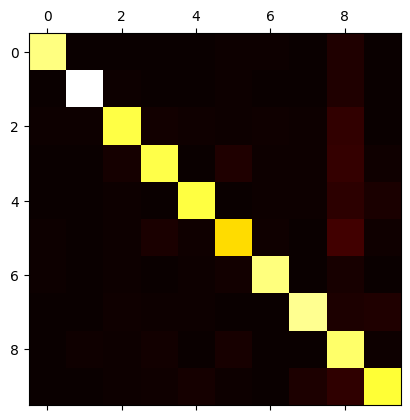

In [51]:
#Plot a image representation
plt.matshow(conf_mx, cmap=plt.cm.hot)
plt.show()

In [52]:
#Normalize the errors
row_sums = conf_mx.sum(axis=1, keepdims=True)
norm_conf_mx = conf_mx / row_sums

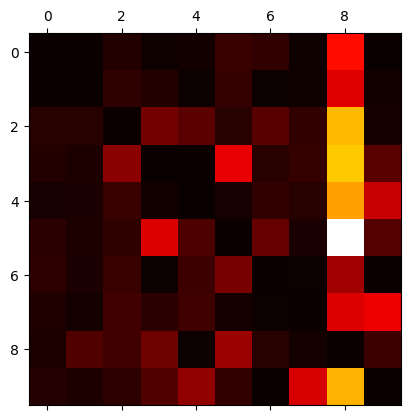

In [53]:
np.fill_diagonal(norm_conf_mx, 0)
plt.matshow(norm_conf_mx, cmap=plt.cm.hot)
plt.show()

In [54]:
#Analyzing individual errors
cl_a, cl_b = 3, 5
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

In [55]:
# EXTRA
def plot_digits(instances, images_per_row=10, **options):
    size = 28
    images_per_row = min(len(instances), images_per_row)
    # This is equivalent to n_rows = ceil(len(instances) / images_per_row):
    n_rows = (len(instances) - 1) // images_per_row + 1

    # Append empty images to fill the end of the grid, if needed:
    n_empty = n_rows * images_per_row - len(instances)
    padded_instances = np.concatenate([instances, np.zeros((n_empty, size * size))], axis=0)

    # Reshape the array so it's organized as a grid containing 28×28 images:
    image_grid = padded_instances.reshape((n_rows, images_per_row, size, size))

    # Combine axes 0 and 2 (vertical image grid axis, and vertical image axis),
    # and axes 1 and 3 (horizontal axes). We first need to move the axes that we
    # want to combine next to each other, using transpose(), and only then we
    # can reshape:
    big_image = image_grid.transpose(0, 2, 1, 3).reshape(n_rows * size,
                                                         images_per_row * size)
    # Now that we have a big image, we just need to show it:
    plt.imshow(big_image, cmap = mpl.cm.binary, **options)
    plt.axis("off")

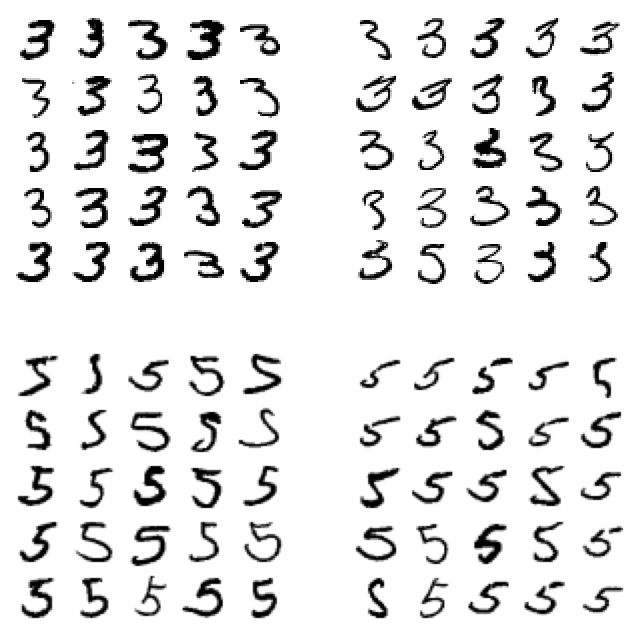

In [56]:
plt.figure(figsize=(8,8))
plt.subplot(221); plot_digits(X_aa[:25], images_per_row=5)
plt.subplot(222); plot_digits(X_ab[:25], images_per_row=5)
plt.subplot(223); plot_digits(X_ba[:25], images_per_row=5)
plt.subplot(224); plot_digits(X_bb[:25], images_per_row=5)
plt.show()

The main difference between 3s and 5s is the position of the small line that joing the top line to the bottom arc. In other words,**this classifier is quite sensitive to image shifting and rotation.**

## Multilabel Classification

In [57]:
#Create a multilabel array that indicates whether or not the digit is larger than 7 
# and whether or not the digit is odd.
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= 7)
y_train_odd = (y_train % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd] 

In [58]:
knn_clf = KNeighborsClassifier(n_jobs=-1)
knn_clf.fit(X_train, y_multilabel)

KNeighborsClassifier(n_jobs=-1)

In [59]:
knn_clf.predict([some_digit])

array([[False,  True]])

In [60]:
#Evaluate the classifier by measuring F1 score and computing the average score.
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3, n_jobs=-1)
f1_score(y_multilabel, y_train_knn_pred, average="macro")

0.9764102655606048

## Multioutput Classification

In [61]:
#Create training and test sets from MNIST images and add noise randomly
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise

noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise

y_train_mod = X_train
y_test_mod = X_test

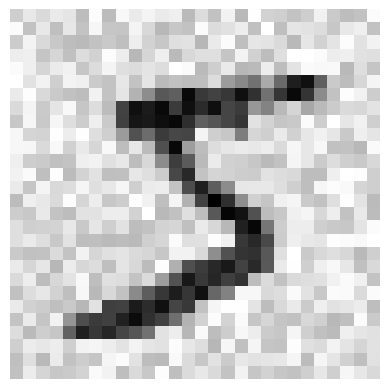

In [62]:
some_index = X_train_mod[0]
some_index_image = some_index.reshape(28, 28)

plt.imshow(some_index_image, cmap=mpl.cm.binary)
plt.axis('off')
plt.show()

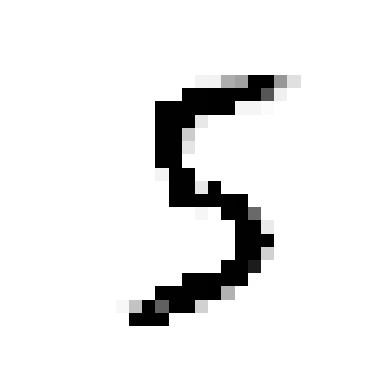

In [63]:
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([some_index])
clean_digit_image = clean_digit.reshape(28, 28)

plt.imshow(clean_digit_image, cmap=mpl.cm.binary)
plt.axis('off')
plt.show()

## Esercises

1.

In [64]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf_multi = KNeighborsClassifier(n_jobs=-1)
knn_clf_multi.fit(X_train, y_train)

KNeighborsClassifier(n_jobs=-1)

In [65]:
cross_val_score(knn_clf_multi, X_train, y_train, cv=3, scoring="accuracy", n_jobs=-1)

array([0.9676 , 0.9671 , 0.96755])

In [66]:
#Fine-tune KNeighborsClassifier Model with Grid Search
from sklearn.model_selection import GridSearchCV

param_grid = [
    {"n_neighbors": [10, 15, 25, 50], "weights": ['uniform','distance']},
]

knn_clf_multi = KNeighborsClassifier()

grid_search = GridSearchCV(knn_clf_multi, param_grid, cv=5,
                           scoring="accuracy",
                           return_train_score=True,
                           n_jobs=-1
                           )

grid_search.fit(X_train, y_train)

/Users/alinemitri/.pyenv/versions/3.10.15/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid=[{'n_neighbors': [10, 15, 25, 50],
                          'weights': ['uniform', 'distance']}],
             return_train_score=True, scoring='accuracy')

In [67]:
knn_clf_better = KNeighborsClassifier(n_neighbors=10, weights='distance', n_jobs=-1)
knn_clf_better.fit(X_train, y_train)

KNeighborsClassifier(n_jobs=-1, n_neighbors=10, weights='distance')

In [68]:
cross_val_score(knn_clf_better, X_train, y_train, cv=3, scoring="accuracy", n_jobs=-1)

array([0.96435, 0.96435, 0.96635])

In [69]:
knn_clf_better.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_jobs=-1, n_neighbors=10, weights='distance')

In [70]:
cross_val_score(knn_clf_better, X_train_scaled, y_train, cv=3, scoring="accuracy", n_jobs=-1)

array([0.935  , 0.9402 , 0.94085])

In [71]:
#Fine-tune KNeighborsClassifier Model with Grid Search
from sklearn.model_selection import GridSearchCV

param_grid = [
    {"n_neighbors": [3, 4, 7, 8], "weights": ['uniform','distance']},
]

knn_clf_multi2 = KNeighborsClassifier()

grid_search = GridSearchCV(knn_clf_multi2, param_grid, cv=5,
                           scoring="accuracy",
                           return_train_score=True,
                           n_jobs=-1
                           )

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid=[{'n_neighbors': [3, 4, 7, 8],
                          'weights': ['uniform', 'distance']}],
             return_train_score=True, scoring='accuracy')

In [72]:
knn_clf_better2 = KNeighborsClassifier(n_neighbors=4, weights='distance', n_jobs=-1)
knn_clf_better2.fit(X_train, y_train)

KNeighborsClassifier(n_jobs=-1, n_neighbors=4, weights='distance')

In [73]:
cross_val_score(knn_clf_better2, X_train, y_train, cv=3, scoring="accuracy", n_jobs=-1)

array([0.9709 , 0.9698 , 0.97035])

In [74]:
knn_clf_better2.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_jobs=-1, n_neighbors=4, weights='distance')

In [75]:
cross_val_score(knn_clf_better2, X_train_scaled, y_train, cv=3, scoring="accuracy", n_jobs=-1)

array([0.9428, 0.9442, 0.9443])

In [76]:
cross_val_score(knn_clf_better2, X_test, y_test, cv=3, scoring="accuracy", n_jobs=-1)

array([0.91841632, 0.9429943 , 0.96189619])

2.

/var/folders/vv/_k5srfb10bv6g7f7b65w5gfw0000gn/T/ipykernel_98825/1509230317.py:1: DeprecationWarning: Please import `shift` from the `scipy.ndimage` namespace; the `scipy.ndimage.interpolation` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.interpolation import shift


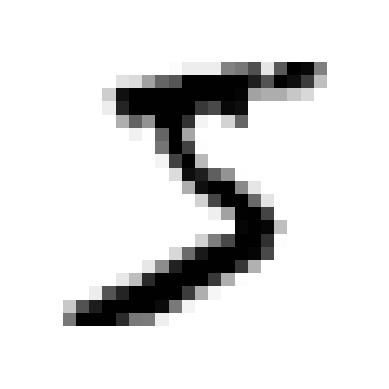

In [80]:
from scipy.ndimage.interpolation import shift

some_digit_image = some_digit.reshape(28, 28)
digit_test = shift(some_digit_image, [-1,0], cval=0)
digit_test_image = digit_test.reshape(28, 28)

plt.imshow(digit_test_image, cmap=mpl.cm.binary)
plt.axis('off')
plt.show()

In [88]:
some_digit2 = some_digit_image.reshape(-1)

In [89]:
(some_digit2 == some_digit).all()

np.True_

In [100]:
def four_shift(array):
    array_image = array.reshape(28, 28)
    shift_right = shift(array_image, [0, 1], cval=0)
    shift_left = shift(array_image, [0, -1], cval=0)
    shift_down = shift(array_image, [1, 0], cval=0)
    shift_up = shift(array_image, [-1, 0], cval=0)
    
    array_right = shift_right.reshape(-1)
    array_left = shift_left.reshape(-1)
    array_down = shift_down.reshape(-1)
    array_up = shift_up.reshape(-1)
    
    return np.array([array_right, array_left, array_down, array_up])

In [91]:
a,b,c,d = four_shift(some_digit)

In [92]:
def reshape_array (array):
    array_image = array.reshape(28, 28)

    plt.imshow(array_image, cmap=mpl.cm.binary)
    plt.axis('off')
    plt.show()

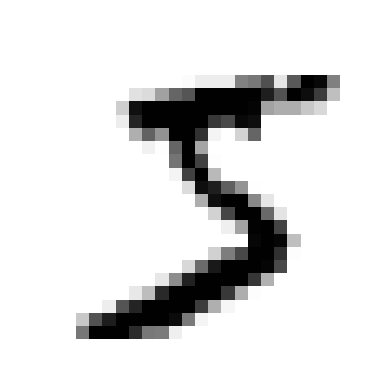

In [93]:
reshape_array(a)

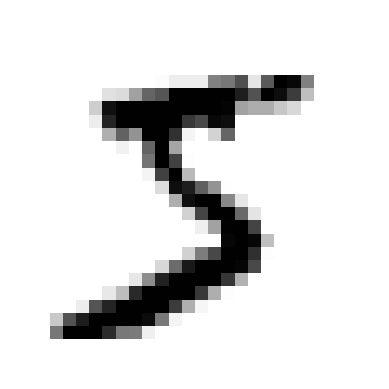

In [94]:
reshape_array(b)

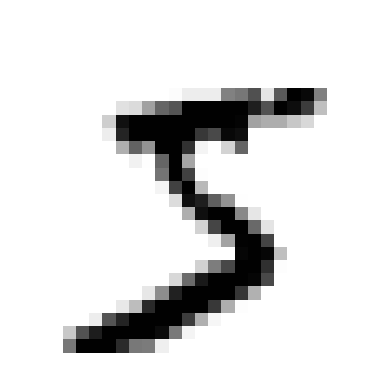

In [95]:
reshape_array(c)

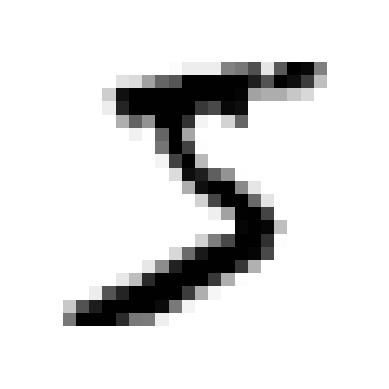

In [96]:
reshape_array(d)

In [97]:
test = np.array(some_digit)

In [101]:
X_new = np.concatenate([X_train] + [four_shift(x) for x in X_train])

In [104]:
X_new.shape

(300000, 784)

In [105]:
X_train.shape

(60000, 784)

In [107]:
y_new = np.concatenate([y_train] + [[y,y,y,y] for y in y_train])

In [108]:
y_new.shape

(300000,)

In [109]:
knn_clf_2 = KNeighborsClassifier(n_neighbors=4, weights='distance', n_jobs=-1)
knn_clf_2.fit(X_new, y_new)

KNeighborsClassifier(n_jobs=-1, n_neighbors=4, weights='distance')

In [110]:
cross_val_score(knn_clf_2, X_new, y_new, cv=3, scoring="accuracy", n_jobs=-1)

array([0.98389, 0.98128, 0.98026])

In [111]:
cross_val_score(knn_clf_2, X_test, y_test, cv=3, scoring='accuracy', n_jobs=-1)

array([0.91841632, 0.9429943 , 0.96189619])